# Conditional VAE — FashionMNIST × ABSA Sentiment

**Input:** `absa_longformer_results.csv` (aspect, sentiment, confidence, doc_id)  
**Image data:** FashionMNIST 28×28 grayscale  
**Condition vector c:** concat(one-hot sentiment 3-d, Word2Vec aspect 100-d) = 103-d  
**Output:** trained CVAE + `augmented_dataset.csv` + generated images

**Sentiment distribution trong ABSA output:**
- neutral : 210 335 (57%)
- negative: 125 973 (34%)
- positive:  33 154 ( 9%)

→ Generation quota sẽ **cân bằng lại** về 1:1:1 để augment dataset cho multimodal training.

## 0. Install & Config

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install tensorflow gensim numpy pandas matplotlib tqdm Pillow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.5 MB/s eta 0:00:00


In [5]:
import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Paths ──────────────────────────────────────────────────────────────────
ABSA_CSV       = r"/content/drive/MyDrive/ONTAP9TR/capstone 3/absa_longformer_results.csv"
OUTPUT_DIR     = r"/content/drive/MyDrive/ONTAP9TR/capstone 3/"
OUTPUT_CSV     = r"/content/drive/MyDrive/ONTAP9TR/capstone 3/augmented_dataset.csv"
CHECKPOINT_DIR = r"/ONTAP9TR/cvae_checkpoint"

# ── VAE architecture (phải nhất quán giữa train và generate) ───────────────
IMG_H, IMG_W   = 28, 28
LATENT_DIM     = 64
W2V_DIM        = 100
N_SENTIMENTS   = 3                        # positive / neutral / negative
CONDITION_DIM  = N_SENTIMENTS + W2V_DIM   # 103

# ── Training ───────────────────────────────────────────────────────────────
BATCH_SIZE     = 256
EPOCHS         = 150
BETA           = 0.001   # KL weight; tăng lên 4 nếu muốn disentangled latent
LEARNING_RATE  = 1e-3

# ── Generation quota (balanced) ────────────────────────────────────────────
N_GEN_PER_SENTIMENT = 1000   # generate 1000 ảnh/sentiment → cân bằng dataset

LABEL2IDX = {"positive": 0, "neutral": 1, "negative": 2}
IDX2LABEL = {v: k for k, v in LABEL2IDX.items()}

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"Condition vector dim: {CONDITION_DIM}")

TensorFlow: 2.20.0
GPU: []
Condition vector dim: 103


## 1. Load & Process ABSA Output

Từ `absa_longformer_results.csv` ta cần:
1. Aggregate per-document sentiment profile
2. Build Word2Vec trên tập aspect terms
3. Tạo condition vector `c` cho mỗi document

In [6]:
df_absa = pd.read_csv(ABSA_CSV)

print(f"ABSA records : {len(df_absa):,}")
print(f"Unique docs  : {df_absa['doc_id'].nunique():,}")
print(f"\nSentiment distribution:")
print(df_absa['sentiment'].value_counts())
print(f"\nSample aspects: {df_absa['aspect'].dropna().head(8).tolist()}")

ABSA records : 369,462
Unique docs  : 32,105

Sentiment distribution:
sentiment
neutral     210335
negative    125973
positive     33154
Name: count, dtype: int64

Sample aspects: ['section', 'statistics', 'accidents', 'references', 'ie date format', 'nominations', 'transport', 'use']


In [7]:
# ── Per-document sentiment profile ─────────────────────────────────────────
def build_doc_profile(df):
    profiles = []
    for doc_id, grp in df.groupby("doc_id"):
        ratios   = grp["sentiment"].value_counts(normalize=True)
        dominant = ratios.idxmax()
        aspects  = grp["aspect"].dropna().tolist()
        profiles.append({
            "doc_id":    doc_id,
            "dominant":  dominant,
            "pos_ratio": ratios.get("positive", 0.0),
            "neu_ratio": ratios.get("neutral",  0.0),
            "neg_ratio": ratios.get("negative", 0.0),
            "aspects":   aspects,
            "avg_conf":  round(grp["confidence"].mean(), 4),
        })
    return pd.DataFrame(profiles)

df_profiles = build_doc_profile(df_absa)
print(f"Document profiles: {len(df_profiles):,}")
print("\nDominant sentiment per doc:")
print(df_profiles["dominant"].value_counts())

Document profiles: 32,105

Dominant sentiment per doc:
dominant
neutral     17377
negative    12273
positive     2455
Name: count, dtype: int64


In [8]:
from gensim.models import Word2Vec

# Train Word2Vec trên aspect terms từ ABSA output
aspect_sentences = [
    str(asp).lower().split()
    for asp in df_absa["aspect"].dropna()
]

w2v = Word2Vec(
    sentences=aspect_sentences,
    vector_size=W2V_DIM,
    window=5,
    min_count=1,
    workers=4,
    epochs=10,
    seed=42,
)
print(f"Word2Vec vocab: {len(w2v.wv):,} terms")


def text_to_vec(text: str) -> np.ndarray:
    """Mean-pool word vectors. Zero vector nếu OOV."""
    tokens = str(text).lower().split()
    vecs   = [w2v.wv[t] for t in tokens if t in w2v.wv]
    return np.mean(vecs, axis=0).astype(np.float32) if vecs else np.zeros(W2V_DIM, dtype=np.float32)


def build_condition_vector(sentiment_label: str, aspect_text: str = "") -> np.ndarray:
    """c = concat(one_hot(sentiment, 3), word2vec(aspect, 100)) → shape (103,)"""
    one_hot       = np.zeros(N_SENTIMENTS, dtype=np.float32)
    one_hot[LABEL2IDX.get(sentiment_label, 1)] = 1.0
    w2v_vec       = text_to_vec(aspect_text)
    return np.concatenate([one_hot, w2v_vec])


# Build condition vectors cho mỗi document (dùng dominant sentiment + mean aspect)
def doc_condition_vector(row) -> np.ndarray:
    """Mean-pool condition vectors của tất cả aspects trong document."""
    aspects = row["aspects"] if isinstance(row["aspects"], list) else []
    if not aspects:
        return build_condition_vector(row["dominant"])
    vecs = [build_condition_vector(row["dominant"], asp) for asp in aspects]
    return np.mean(vecs, axis=0).astype(np.float32)

df_profiles["condition_vec"] = df_profiles.apply(doc_condition_vector, axis=1)

# Verify
test_c = df_profiles.iloc[0]["condition_vec"]
assert test_c.shape == (CONDITION_DIM,), f"Expected ({CONDITION_DIM},), got {test_c.shape}"
print(f"\nCondition vector shape: {test_c.shape} ✓")

Word2Vec vocab: 27,461 terms

Condition vector shape: (103,) ✓


## 2. Load & Prepare FashionMNIST

Gán **sentiment label giả** cho FashionMNIST dựa trên class id:
- Class 0–3 (áo các loại, sáng màu) → **positive**
- Class 4–6 (coat, sandal, shirt) → **neutral**  
- Class 7–9 (sneaker, bag, boot) → **negative**

Sau đó pair mỗi ảnh FashionMNIST với condition vector từ ABSA document cùng sentiment.

In [9]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_all = np.concatenate([x_train, x_test], axis=0).astype(np.float32) / 255.0
y_all = np.concatenate([y_train, y_test], axis=0)

# Reshape → (N, 28, 28, 1)
x_all = x_all[..., np.newaxis]

# Gán sentiment label cho class id
CLASS_SENTIMENT = {
    0: "positive",  # T-shirt/top
    1: "positive",  # Trouser
    2: "positive",  # Pullover
    3: "positive",  # Dress
    4: "neutral",   # Coat
    5: "neutral",   # Sandal
    6: "neutral",   # Shirt
    7: "negative",  # Sneaker
    8: "negative",  # Bag
    9: "negative",  # Ankle boot
}
sent_labels = np.array([CLASS_SENTIMENT[c] for c in y_all])

print(f"FashionMNIST: {x_all.shape}  dtype: {x_all.dtype}")
print("Sentiment mapping:")
for s in ["positive", "neutral", "negative"]:
    print(f"  {s:10s}: {(sent_labels == s).sum():,} images")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
FashionMNIST: (70000, 28, 28, 1)  dtype: float32
Sentiment mapping:
  positive  : 28,000 images
  neutral   : 21,000 images
  negative  : 21,000 images


In [10]:
# ── Pair mỗi ảnh FashionMNIST với condition vector ABSA cùng sentiment ─────
# Index ABSA profiles theo dominant sentiment để lookup nhanh
absa_by_sent = {
    s: df_profiles[df_profiles["dominant"] == s]["condition_vec"].tolist()
    for s in ["positive", "neutral", "negative"]
}
for s, vecs in absa_by_sent.items():
    print(f"  ABSA {s:10s} pool: {len(vecs):,} condition vectors")


def get_condition_for_image(idx: int, sentiment: str) -> np.ndarray:
    """Lấy condition vector ABSA tương ứng sentiment bằng round-robin."""
    pool = absa_by_sent[sentiment]
    if not pool:
        return build_condition_vector(sentiment)  # fallback: no aspect
    return pool[idx % len(pool)]


# Build condition matrix C cho toàn bộ dataset
print("\nBuilding condition matrix...")
C_all = np.array([
    get_condition_for_image(i, sent_labels[i])
    for i in range(len(x_all))
], dtype=np.float32)

print(f"Image matrix  X: {x_all.shape}")
print(f"Condition matrix C: {C_all.shape}")

# Train / val split 85/15
train_split = int(0.7 * len(x_all))
val_split = int(0.85 * len(x_all))  # 0.7 + 0.15

X_train = x_all[:train_split]
X_val   = x_all[train_split:val_split]
X_test  = x_all[val_split:]

C_train = C_all[:train_split]
C_val   = C_all[train_split:val_split]
C_test  = C_all[val_split:]

print(f"\nTrain: {X_train.shape[0]:,}")
print(f"Val:   {X_val.shape[0]:,}")
print(f"Test:  {X_test.shape[0]:,}")

  ABSA positive   pool: 2,455 condition vectors
  ABSA neutral    pool: 17,377 condition vectors
  ABSA negative   pool: 12,273 condition vectors

Building condition matrix...
Image matrix  X: (70000, 28, 28, 1)
Condition matrix C: (70000, 103)

Train: 49,000
Val:   10,500
Test:  10,500


## 3. Build Conditional VAE (Keras)

**Encoder:** Conv2D → Flatten → concat(c) → Dense → μ, log σ²  
**Sampling:** z = μ + ε·σ (reparameterization trick)  
**Decoder:** concat(z, c) → Dense → Reshape → Conv2DTranspose → sigmoid output

In [11]:
# ── Sampling layer ──────────────────────────────────────────────────────────
class Sampling(layers.Layer):
    """Reparameterization trick: z = mu + eps*sigma, eps ~ N(0,I)"""
    def call(self, inputs):
        mu, log_var = inputs
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * eps


# ── Encoder ─────────────────────────────────────────────────────────────────
def build_encoder(latent_dim: int, condition_dim: int):
    img_input = keras.Input(shape=(IMG_H, IMG_W, 1),  name="img_input")
    c_input   = keras.Input(shape=(condition_dim,),    name="c_input")

    # 3 Conv blocks theo PDF (16 → 32 → 64)
    x = layers.Conv2D(16, 3, padding="same", use_bias=False)(img_input)  # 28×28×16
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(32, 3, strides=2, padding="same", use_bias=False)(x)  # 14×14×32
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same", use_bias=False)(x)  # 7×7×64
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Flatten()(x)                                                   # 3136

    # Concat condition vector
    x = layers.Concatenate()([x, c_input])                                    # 3136 + 103
    x = layers.Dense(512, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    mu      = layers.Dense(latent_dim, name="mu")(x)
    log_var = layers.Dense(latent_dim, name="log_var")(x)
    z       = Sampling(name="z")([mu, log_var])

    return keras.Model([img_input, c_input], [mu, log_var, z], name="encoder")


# ── Decoder ─────────────────────────────────────────────────────────────────
def build_decoder(latent_dim: int, condition_dim: int):
    z_input = keras.Input(shape=(latent_dim,),     name="z_input")
    c_input = keras.Input(shape=(condition_dim,),  name="c_input")

    x = layers.Concatenate()([z_input, c_input])
    x = layers.Dense(512, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dense(7 * 7 * 64, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Reshape((7, 7, 64))(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", use_bias=False)(x)  # 14×14×64
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", use_bias=False)(x)  # 28×28×32
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(16, 3, padding="same", use_bias=False)(x)                      # 28×28×16
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    output = layers.Conv2D(1, 1, activation="sigmoid", padding="same")(x)            # 28×28×1

    return keras.Model([z_input, c_input], output, name="decoder")


encoder = build_encoder(LATENT_DIM, CONDITION_DIM)
decoder = build_decoder(LATENT_DIM, CONDITION_DIM)

encoder.summary()
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input           │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        144 │ img_input[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │      4,608 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 64)  │     18,432 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 64)  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 7, 7, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c_input             │ (None, 103)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3239)      │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ c_input[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,658,368 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 64)        │     32,832 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 64)        │     32,832 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,749,712 (6.67 MB)

 Trainable params: 1,748,464 (6.67 MB)

 Non-trainable params: 1,248 (4.88 KB)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ z_input             │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c_input             │ (None, 103)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 167)       │          0 │ z_input[0][0],    │
│ (Concatenate)       │                   │            │ c_input[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │     85,504 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3136)      │  1,605,632 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3136)      │     12,544 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 3136)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 7, 7, 64)  │          0 │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 14, 14,    │     36,864 │ reshape[0][0]     │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 28, 28,    │     18,432 │ activation_6[0][… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │      4,608 │ activation_7[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │         64 │ conv2d_3[0][0]  

 Total params: 1,766,097 (6.74 MB)

 Trainable params: 1,758,577 (6.71 MB)

 Non-trainable params: 7,520 (29.38 KB)

In [12]:
# ── Full CVAE model ──────────────────────────────────────────────────────────
IMG_FLAT = IMG_H * IMG_W   # 784 — normalisation constant

class CVAE(keras.Model):
    def __init__(self, encoder, decoder, beta_max=0.5, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        # tf.Variable permite update via callback sem recompilar
        self.beta    = tf.Variable(0.0, trainable=False, dtype=tf.float32)
        self.beta_max = beta_max

        # Metrics
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker    = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def _compute_loss(self, x_img, c_vec, training):
        mu, log_var, z = self.encoder([x_img, c_vec], training=training)
        x_recon        = self.decoder([z, c_vec],     training=training)

        # Reconstruction loss: sum pixels → mean over batch → normalize by IMG_FLAT
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(
                keras.losses.binary_crossentropy(x_img, x_recon),
                axis=(1, 2)
            )
        ) / IMG_FLAT

        # KL divergence: sum over latent dims → mean over batch (không chia IMG_FLAT)
        # Theo PDF: KL scale độc lập với reconstruction, beta cân bằng hai thành phần
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
        )

        total_loss = recon_loss + self.beta * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x_img, c_vec = data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_loss(x_img, c_vec, training=True)
        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x_img, c_vec = data
        total_loss, recon_loss, kl_loss = self._compute_loss(x_img, c_vec, training=False)
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def call(self, inputs):
        x_img, c_vec = inputs
        mu, log_var, z = self.encoder([x_img, c_vec])
        return self.decoder([z, c_vec])


cvae = CVAE(encoder, decoder, beta_max=BETA)
cvae.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE))
print("CVAE compiled ✓")
print(f"Initial beta = {cvae.beta.numpy():.3f}  (will anneal to {BETA})")
cvae.summary()

CVAE compiled ✓
Initial beta = 0.000  (will anneal to 0.001)


Model: "cvae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 64), (None,    │     1,749,712 │
│                                 │ 64), (None, 64))       │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │     1,766,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,515,809 (13.41 MB)

 Trainable params: 3,507,041 (13.38 MB)

 Non-trainable params: 8,768 (34.25 KB)

## 4. Train

In [13]:
# ── tf.data pipeline ─────────────────────────────────────────────────────────
def make_dataset(X, C, batch_size, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X, C))
    if shuffle:
        ds = ds.shuffle(10_000, seed=42)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train, C_train, BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(X_val,   C_val,   BATCH_SIZE, shuffle=False)
test_ds  = make_dataset(X_test,  C_test,  BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_ds)}")
print(f"Val batches  : {len(val_ds)}")
print(f"Test batches : {len(test_ds)}")

Train batches: 192
Val batches  : 42
Test batches : 42


In [14]:
class BetaAnnealing(keras.callbacks.Callback):
    def __init__(self, warmup_epochs=40, beta_max=BETA):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.beta_max      = beta_max
    def on_epoch_begin(self, epoch, logs=None):
        new_beta = min(self.beta_max, self.beta_max * (epoch + 1) / self.warmup_epochs)
        self.model.beta.assign(new_beta)

callbacks = [
    BetaAnnealing(warmup_epochs=40, beta_max=BETA),
    # Save best checkpoint theo val total_loss
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(CHECKPOINT_DIR, "cvae_best.weights.h5"),
        save_weights_only=True,
        monitor="val_total_loss",
        save_best_only=True,
        verbose=1,
        mode="min", # Added mode='min'
    ),
    # Early stopping nếu val_total_loss không giảm sau 8 epochs
    keras.callbacks.EarlyStopping(
        monitor="val_total_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1,
        mode="min", # Added mode='min'
    ),
    # Reduce LR on plateau
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_total_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-5,
        verbose=1,
        mode="min", # Added mode='min'
    ),
]

In [17]:
cvae.build([(None, IMG_H, IMG_W, 1), (None, CONDITION_DIM)])
history = cvae.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - kl_loss: 131.6446 - recon_loss: 0.2725 - total_loss: 0.2758
Epoch 1: val_total_loss improved from 0.31206 to 0.27562, saving model to /ONTAP9TR/cvae_checkpoint/cvae_best.weights.h5

Epoch 1: finished saving model to /ONTAP9TR/cvae_checkpoint/cvae_best.weights.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - kl_loss: 132.5761 - recon_loss: 0.2713 - total_loss: 0.2746 - val_kl_loss: 133.6539 - val_recon_loss: 0.2723 - val_total_loss: 0.2756 - learning_rate: 0.0010
Epoch 2/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - kl_loss: 114.4550 - recon_loss: 0.2683 - total_loss: 0.2740
Epoch 2: val_total_loss improved from 0.27562 to 0.27497, saving model to /ONTAP9TR/cvae_checkpoint/cvae_best.weights.h5

Epoch 2: finished saving model to /ONTAP9TR/cvae_checkpoint/cvae_best.weights.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - kl_loss: 111.9053 - recon_loss: 0.2676 - total_loss: 0.2732 - val_kl_loss: 117.7514 - val_recon_loss: 0.2691 - val_total

Đã lưu biểu đồ total_loss tại: /content/drive/MyDrive/ONTAP9TR/capstone 3/cvae_total_loss.png


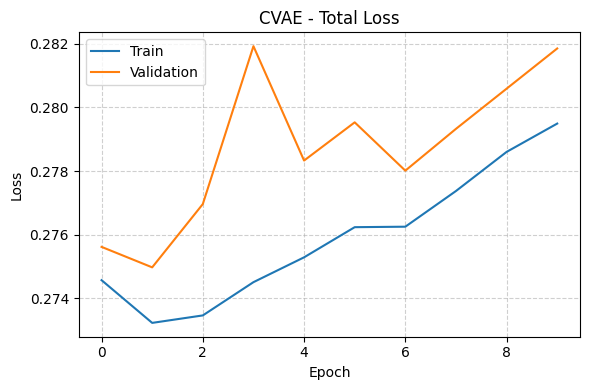

Đã lưu biểu đồ recon_loss tại: /content/drive/MyDrive/ONTAP9TR/capstone 3/cvae_recon_loss.png


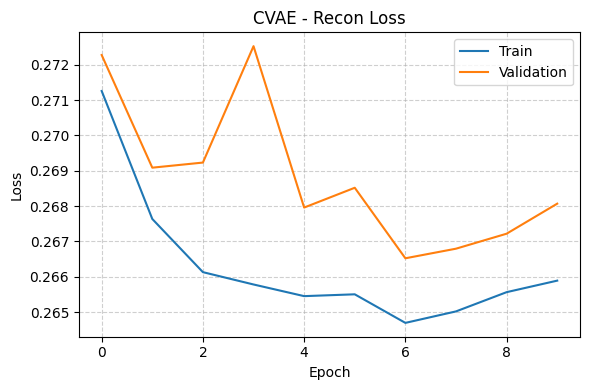

Đã lưu biểu đồ kl_loss    tại: /content/drive/MyDrive/ONTAP9TR/capstone 3/cvae_kl_loss.png


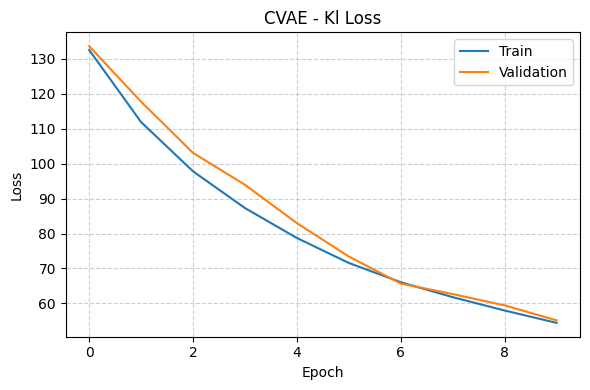


Final val total_loss: 0.2818


In [18]:
import os
import matplotlib.pyplot as plt

# Định nghĩa thư mục lưu - đảm bảo thư mục này tồn tại
SAVE_DIR = "/content/drive/MyDrive/ONTAP9TR/capstone 3"
os.makedirs(SAVE_DIR, exist_ok=True)

metrics = ["total_loss", "recon_loss", "kl_loss"]

# Duyệt qua từng metric để vẽ và lưu độc lập
for metric in metrics:
    # 1. Khởi tạo một khung hình độc lập cho mỗi metric
    plt.figure(figsize=(6, 4))

    # 2. Vẽ đường train và val
    plt.plot(history.history[metric],         label="Train")
    plt.plot(history.history[f"val_{metric}"], label="Validation")

    # 3. Trang trí biểu đồ
    plt.title(f"CVAE - {metric.replace('_', ' ').title()}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)  # Thêm lưới nhìn cho chuyên nghiệp
    plt.tight_layout()

    # 4. Lưu từng file riêng biệt theo tên metric
    file_path = os.path.join(SAVE_DIR, f"cvae_{metric}.png")
    plt.savefig(file_path, dpi=120)
    print(f"Đã lưu biểu đồ {metric:10s} tại: {file_path}")

    # 5. Hiển thị và đóng figure hiện tại để giải phóng bộ nhớ
    plt.show()
    plt.close()

# In kết quả final loss cuối cùng như cũ
final_loss = history.history["val_total_loss"][-1]
print(f"\nFinal val total_loss: {final_loss:.4f}")

## 5. Save Model

In [19]:
import os

# Redefine CHECKPOINT_DIR for Google Colab environment
CHECKPOINT_DIR = "/content/drive/MyDrive/ONTAP9TR/cvae_checkpoint"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Save encoder và decoder riêng để dễ load lại khi generate
encoder.save(os.path.join(CHECKPOINT_DIR, "encoder.keras"))
decoder.save(os.path.join(CHECKPOINT_DIR, "decoder.keras"))

# Save Word2Vec
w2v.save(os.path.join(CHECKPOINT_DIR, "w2v_aspects.model"))

print("Saved:")
print(f"  {CHECKPOINT_DIR}/encoder.keras")
print(f"  {CHECKPOINT_DIR}/decoder.keras")
print(f"  {CHECKPOINT_DIR}/w2v_aspects.model")

Saved:
  /content/drive/MyDrive/ONTAP9TR/cvae_checkpoint/encoder.keras
  /content/drive/MyDrive/ONTAP9TR/cvae_checkpoint/decoder.keras
  /content/drive/MyDrive/ONTAP9TR/cvae_checkpoint/w2v_aspects.model


## 6. Generate Images per Sentiment

Dùng decoder trực tiếp (không qua encoder). Sample z từ prior N(0,I), condition vector `c` lấy từ ABSA aspect pool tương ứng sentiment.

**Quota:** 1000 ảnh/sentiment → cân bằng lại distribution (ABSA output: 57% neutral, 34% negative, 9% positive).

In [20]:
from PIL import Image
from tqdm.auto import tqdm
import numpy as np
import os

# 1. Cập nhật hàm pool để trả về kèm danh sách aspect text tương ứng
def build_condition_pool(sentiment: str, n: int):
    """
    Tạo n condition vectors và trả về kèm list aspect tương ứng (đã xử lý sạch).
    """
    aspects_pool = df_absa[df_absa["sentiment"] == sentiment]["aspect"].dropna().tolist()
    if not aspects_pool:
        aspects_pool = ["product"]

    vecs = []
    chosen_aspects = []

    for i in range(n):
        asp = aspects_pool[i % len(aspects_pool)]
        vecs.append(build_condition_vector(sentiment, asp))
        chosen_aspects.append(asp)

    return np.array(vecs, dtype=np.float32), chosen_aspects


generated_records = []

for sentiment in ["positive", "neutral", "negative"]:
    n = N_GEN_PER_SENTIMENT
    # Lấy cả vector và list text đi kèm một cách đồng bộ
    c_pool, chosen_aspects = build_condition_pool(sentiment, n)          # (n, 103), list len n
    z = np.random.randn(n, LATENT_DIM).astype(np.float32)  # (n, 32)

    # Decode in batches tránh OOM
    images = decoder.predict([z, c_pool], batch_size=256, verbose=0)  # (n, 28, 28, 1)

    sent_dir = os.path.join(OUTPUT_DIR, sentiment)
    os.makedirs(sent_dir, exist_ok=True)

    for i, img in enumerate(tqdm(images, desc=f"Saving {sentiment}", leave=False)):
        # Xử lý pixel và lưu ảnh (Đoạn này cũ của bạn đã chạy đúng)
        img_uint8 = (img.squeeze() * 255).clip(0, 255).astype(np.uint8)
        img_path  = os.path.join(sent_dir, f"{i:05d}.png")
        Image.fromarray(img_uint8, mode="L").save(img_path)

        # LẤY LUÔN ASPECT TỪ LIST ĐỒNG BỘ - Không sợ lệch, không sợ crash
        asp_text = chosen_aspects[i]

        generated_records.append({
            "image_path": img_path,
            "sentiment":  sentiment,
            "aspect":     asp_text,
            "source":     "vae_generated",
            "doc_id":     f"gen_{sentiment}_{i}",
        })

    print(f"  {sentiment:10s}: {n} images → {sent_dir}/")

print(f"\nTotal generated: {len(generated_records)}")

Saving positive:   0%|          | 0/1000 [00:00<?, ?it/s]

  positive  : 1000 images → /content/drive/MyDrive/ONTAP9TR/capstone 3/positive/


Saving neutral:   0%|          | 0/1000 [00:00<?, ?it/s]

  neutral   : 1000 images → /content/drive/MyDrive/ONTAP9TR/capstone 3/neutral/


Saving negative:   0%|          | 0/1000 [00:00<?, ?it/s]

  negative  : 1000 images → /content/drive/MyDrive/ONTAP9TR/capstone 3/negative/

Total generated: 3000


## 7. Build Augmented Dataset CSV

Merge FashionMNIST original + VAE generated → schema cho Multimodal pipeline.

In [21]:
# ── Original FashionMNIST records ────────────────────────────────────────────
orig_dir = os.path.join(OUTPUT_DIR, "original")
os.makedirs(orig_dir, exist_ok=True)

# Sample cân bằng original: N_GEN_PER_SENTIMENT ảnh/sentiment
original_records = []
for sentiment in ["positive", "neutral", "negative"]:
    idx_pool = np.where(sent_labels == sentiment)[0]
    sampled  = np.random.choice(idx_pool, N_GEN_PER_SENTIMENT, replace=False)
    for i, idx in enumerate(sampled):
        img_uint8 = (x_all[idx].squeeze() * 255).astype(np.uint8)
        img_path  = os.path.join(orig_dir, f"{sentiment}_{i:05d}.png")
        Image.fromarray(img_uint8, mode="L").save(img_path)
        original_records.append({
            "image_path": img_path,
            "sentiment":  sentiment,
            "aspect":     "product",
            "source":     "original",
            "doc_id":     f"fashionmnist_{idx}",
        })

print(f"Original records saved: {len(original_records)}")

# ── Merge ────────────────────────────────────────────────────────────────────
df_augmented = pd.concat([
    pd.DataFrame(original_records),
    pd.DataFrame(generated_records),
], ignore_index=True)

df_augmented.to_csv(OUTPUT_CSV, index=False)
print(f"\nAugmented dataset saved → {OUTPUT_CSV}")
print(f"Total records: {len(df_augmented):,}")
print()
print(df_augmented.groupby(["source", "sentiment"]).size().unstack(fill_value=0))

Original records saved: 3000

Augmented dataset saved → /content/drive/MyDrive/ONTAP9TR/capstone 3/augmented_dataset.csv
Total records: 6,000

sentiment      negative  neutral  positive
source                                    
original           1000     1000      1000
vae_generated      1000     1000      1000


## 8. Verify: Original vs Generated per Sentiment

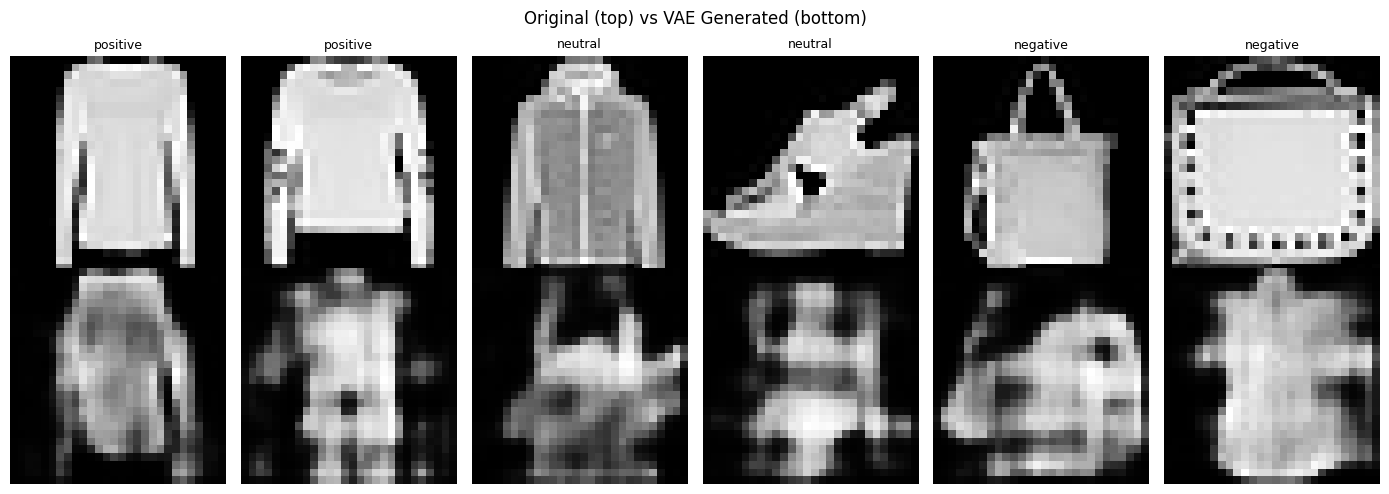

In [22]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle("Original (top) vs VAE Generated (bottom)", fontsize=12)

sentiments = ["positive", "positive", "neutral", "neutral", "negative", "negative"]

for col, sent in enumerate(sentiments):
    pool_orig = df_augmented[(df_augmented["sentiment"] == sent) & (df_augmented["source"] == "original")]
    pool_gen  = df_augmented[(df_augmented["sentiment"] == sent) & (df_augmented["source"] == "vae_generated")]

    if not pool_orig.empty:
        axes[0][col].imshow(np.array(Image.open(pool_orig.iloc[col]["image_path"])), cmap="gray")
    if not pool_gen.empty:
        axes[1][col].imshow(np.array(Image.open(pool_gen.iloc[col]["image_path"])), cmap="gray")

    axes[0][col].set_title(sent, fontsize=9)
    axes[0][col].axis("off")
    axes[1][col].axis("off")

axes[0][0].set_ylabel("Original", fontsize=10)
axes[1][0].set_ylabel("Generated", fontsize=10)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ONTAP9TR/capstone 3/generated_vs_original.png", dpi=120)
plt.show()

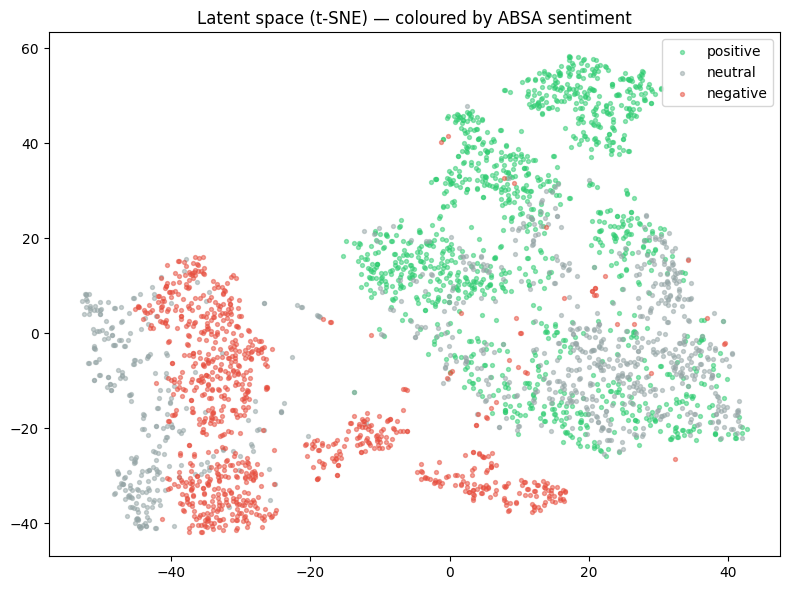

Saved → latent_space_tsne.png


In [23]:
# ── Latent space visualization (t-SNE) ───────────────────────────────────────
from sklearn.manifold import TSNE

# Sample 3000 ảnh để visualize
n_sample = 3000
idx      = np.random.choice(len(X_val), n_sample, replace=False)
mu_all, _, _ = encoder.predict([X_val[idx], C_val[idx]], batch_size=256, verbose=0)

tsne    = TSNE(n_components=2, random_state=42, perplexity=40)
z_2d    = tsne.fit_transform(mu_all)

# Map sentiment labels cho sample
val_sents = np.array([IDX2LABEL[np.argmax(C_val[i][:N_SENTIMENTS])] for i in idx])

fig, ax = plt.subplots(figsize=(8, 6))
colors  = {"positive": "#2ecc71", "neutral": "#95a5a6", "negative": "#e74c3c"}
for sent in ["positive", "neutral", "negative"]:
    mask = val_sents == sent
    ax.scatter(z_2d[mask, 0], z_2d[mask, 1], c=colors[sent], label=sent, alpha=0.5, s=8)

ax.legend()
ax.set_title("Latent space (t-SNE) — coloured by ABSA sentiment")
plt.tight_layout()
plt.savefig("latent_space_tsne.png", dpi=120)
plt.show()
print("Saved → latent_space_tsne.png")

## 9. Summary — Handoff to Multimodal Pipeline

In [24]:
print("=" * 60)
print("CONDITIONAL VAE — SUMMARY")
print("=" * 60)
print(f"ABSA input records        : {len(df_absa):,}")
print(f"Condition vector dim      : {CONDITION_DIM}  (3 one-hot + 100 Word2Vec)")
print(f"Latent dim                : {LATENT_DIM}")
print(f"Final val loss            : {history.history['val_total_loss'][-1]:.4f}")
print()
print("Generated images:")
for sent in ["positive", "neutral", "negative"]:
    n = len([r for r in generated_records if r["sentiment"] == sent])
    print(f"  {sent:10s}: {n:,}")
print()
print("Output files:")
print(f"  {OUTPUT_CSV:<35} ← metadata for Multimodal pipeline")
print(f"  {CHECKPOINT_DIR}/encoder.keras      ← for XAI / feature extraction")
print(f"  {CHECKPOINT_DIR}/decoder.keras      ← for additional generation")
print(f"  {CHECKPOINT_DIR}/w2v_aspects.model  ← reuse in Multimodal condition")
print()
print("Schema của augmented_dataset.csv:")
print("  image_path | sentiment | aspect | source | doc_id")
print("  → BLIP/CLIP nhận image_path")
print("  → ABSA nhận aspect")
print("  → sentiment làm ground-truth label")
print("=" * 60)

CONDITIONAL VAE — SUMMARY
ABSA input records        : 369,462
Condition vector dim      : 103  (3 one-hot + 100 Word2Vec)
Latent dim                : 64
Final val loss            : 0.2818

Generated images:
  positive  : 1,000
  neutral   : 1,000
  negative  : 1,000

Output files:
  /content/drive/MyDrive/ONTAP9TR/capstone 3/augmented_dataset.csv ← metadata for Multimodal pipeline
  /content/drive/MyDrive/ONTAP9TR/cvae_checkpoint/encoder.keras      ← for XAI / feature extraction
  /content/drive/MyDrive/ONTAP9TR/cvae_checkpoint/decoder.keras      ← for additional generation
  /content/drive/MyDrive/ONTAP9TR/cvae_checkpoint/w2v_aspects.model  ← reuse in Multimodal condition

Schema của augmented_dataset.csv:
  image_path | sentiment | aspect | source | doc_id
  → BLIP/CLIP nhận image_path
  → ABSA nhận aspect
  → sentiment làm ground-truth label
